## Imports

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import numpy as np
import os

## Files

In [2]:
img_name = '108_left'
img_path = 'Inputs/' + img_name + '.jpeg'
# retinal_img = "/content/drive/MyDrive/Assignment 1/eye-stroke.jpeg"
# rose = '/content/drive/MyDrive/Assignment 1/Image Histogram.jpg'

## Image Enhancement Class

In [3]:
class ImageEnhancement:
    '''
    A class that is used to generalise the whole
    proces of Image Enhancement using CLAHE and HE
    '''
    def __init__(self,img):
        '''
        path: path to the file
        img: image vector 
        '''
        self.path = img
        self.img = cv2.imread(img)
        self.rgb, self.b, self.g, self.r = self.extract_rgb()
    
    def extract_rgb(self):

        b, g, r = cv2.split(self.img)
        rgb = np.dstack([b, g, r])

        #Displayed the image
        return  rgb, b, g, r

    def image_histogram(self, img=None, plt_title="Image Histogram"):
        '''A function that creates a histogram
        given a image vector
        '''
        # hist,bins = np.histogram()
        if img is None:
            img = self.img
        _ = plt.hist(img.ravel(),256,[0,256])  
        plt.title(plt_title)
        plt.show()
        return 

    def enh_using_clahe(self, B_cl=0, G_cl=0, R_cl=0, show_img=True):
        '''
        A function used to enhance an image using 
        CLAHE
        B_cl : ClipLimit of B channel
        G_cl : ClipLimit of G channel
        R_cl : ClipLimit of R channel       

        '''
        b,g,r = self.b, self.g, self.r
        if B_cl > 0:
            clahe_b = cv2.createCLAHE(B_cl)
            b_enhanced = clahe_b.apply(b)
        else: b_enhanced = b    
        if R_cl > 0:
            clahe_r = cv2.createCLAHE(R_cl)  
            r_enhanced = clahe_r.apply(r)
        else: r_enhanced = r
        if G_cl > 0:
            clahe_g = cv2.createCLAHE(G_cl)
            g_enhanced = clahe_g.apply(g)
        else: g_enhanced = g

        new_rgb = np.dstack([b_enhanced, g_enhanced, r_enhanced])
        if show_img: 
            image = cv2.cvtColor(new_rgb, cv2.COLOR_BGR2RGB)
            plt.imshow(image)
            plt.show()
        return new_rgb

    def enh_using_equ(self):
        '''
        A function to implement Histogram
        Equalization
        '''
        return cv2.equalizeHist(cv2.imread(self.path,0))

## Sample Execution

In [4]:
retinalImage = ImageEnhancement(img_path)
rgb = retinalImage.extract_rgb()

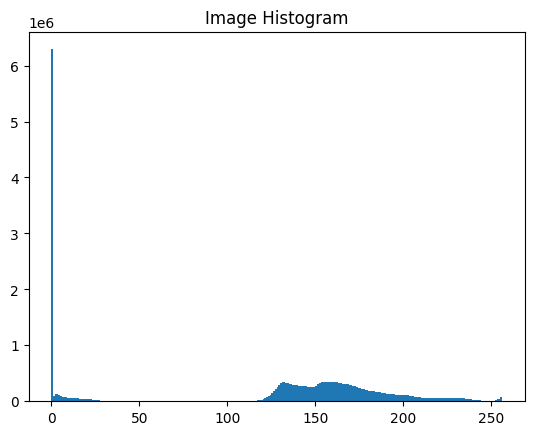

In [5]:
# Image Histogram of Retina Image
retinalImage.image_histogram()

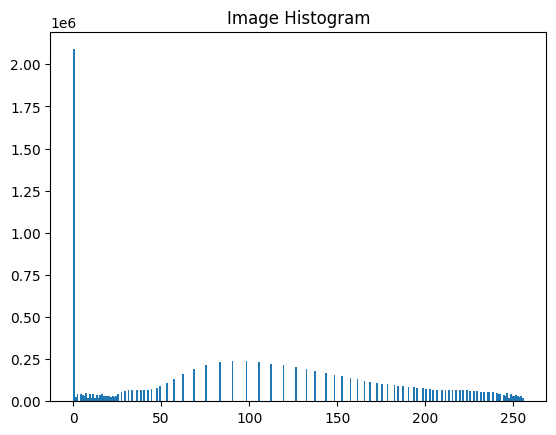

In [6]:
# Image Histogram post Histogram Equalization
equ = retinalImage.enh_using_equ()
retinalImage.image_histogram(equ)

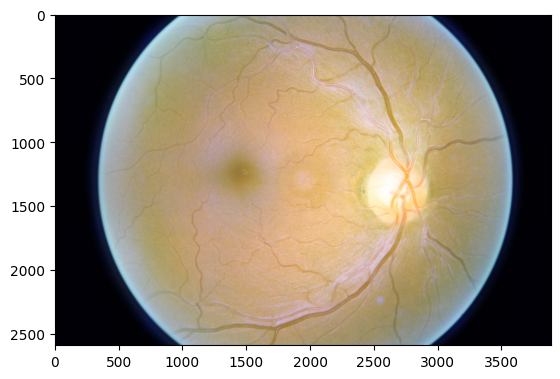

In [7]:
# Applying CLAHE to B channel of the image
clahe_rgb = retinalImage.enh_using_clahe(B_cl=5)

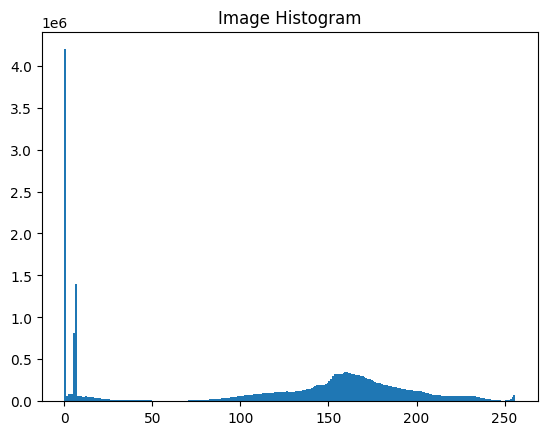

In [8]:
# Histogram after applying CLAHE on B Channel
retinalImage.image_histogram(clahe_rgb)

## Image Histogram w/ Equalization & CLAHE

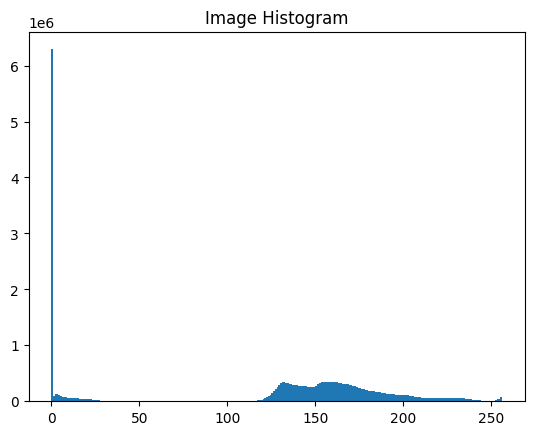

In [9]:
rose_img = ImageEnhancement(img_path)
rose_img.image_histogram()

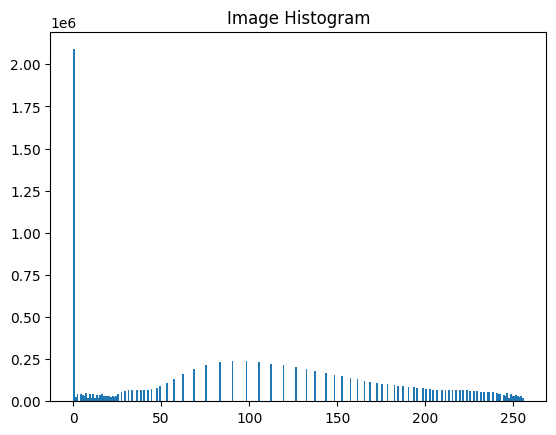

In [10]:
rose_equ_rgb = rose_img.enh_using_equ()
rose_img.image_histogram(rose_equ_rgb)

In [11]:
rose_clahe_rgb = rose_img.enh_using_clahe(B_cl=5, show_img=False)

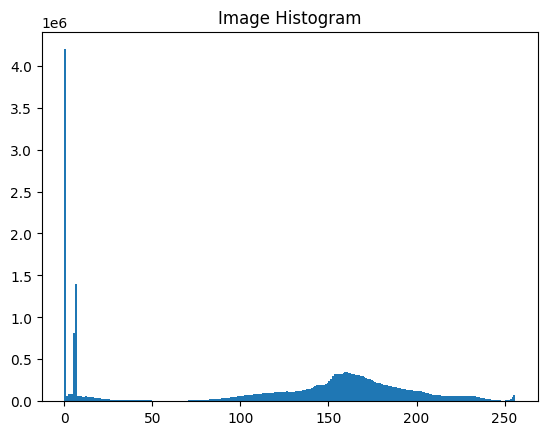

In [12]:
rose_img.image_histogram(rose_clahe_rgb)

# Experimentation Section

### Re-used Function:

In [31]:

def enhance(img,img_name,B_cl=0, G_cl=0, R_cl=0):
    '''
    Same as enh_using_clahe function in 
    ImageEnhancement Class
    '''
    if B_cl > 0:
        clahe_b = cv2.createCLAHE(B_cl)
        b_enhanced = clahe_b.apply(b)
    else: b_enhanced = b    
    if R_cl > 0:
        clahe_r = cv2.createCLAHE(R_cl)  
        r_enhanced = clahe_r.apply(r)
    else: r_enhanced = r
    if G_cl > 0:
        clahe_g = cv2.createCLAHE(G_cl)
        g_enhanced = clahe_g.apply(g)
    else: g_enhanced = g

    new_rgb = np.dstack([b_enhanced, g_enhanced, r_enhanced])
    
    # Display the original and enhanced images side by side
    fig, axes = plt.subplots(1, 5, figsize=(12, 6))
    axes[0].set_title('Original Image')
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].axis('off')

    axes[1].set_title('Blue Channel Enhance')
    axes[1].imshow(cv2.cvtColor(b_enhanced, cv2.COLOR_BGR2RGB))
    axes[1].axis('off')

    axes[2].set_title('Red Channel Enhance')
    axes[2].imshow(cv2.cvtColor(r_enhanced, cv2.COLOR_BGR2RGB))
    axes[2].axis('off')

    axes[3].set_title('Green Channel Enhance')
    axes[3].imshow(cv2.cvtColor(g_enhanced, cv2.COLOR_BGR2RGB))
    axes[3].axis('off')

    axes[4].set_title('Final Image')
    axes[4].imshow(cv2.cvtColor(new_rgb, cv2.COLOR_BGR2RGB))
    axes[4].axis('off')

    if not os.path.exists('Plots'):
        os.mkdir('Plots')

    plt.tight_layout()
    plt.savefig('Plots/' + img_name + '.jpeg', bbox_inches='tight')
    # plt.show()

    if not os.path.exists('Results'):
        os.mkdir('Results')

    cv2.imwrite('Results/' + img_name + '.jpeg', new_rgb)
    
    return new_rgb

## Retinal Image Enhancements - Experimentation

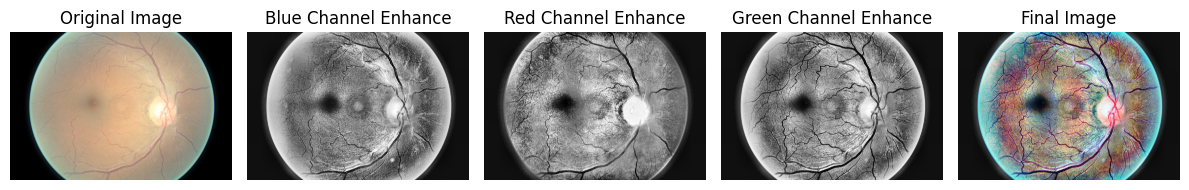

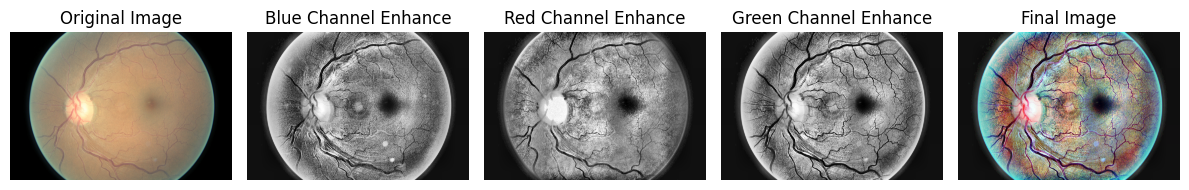

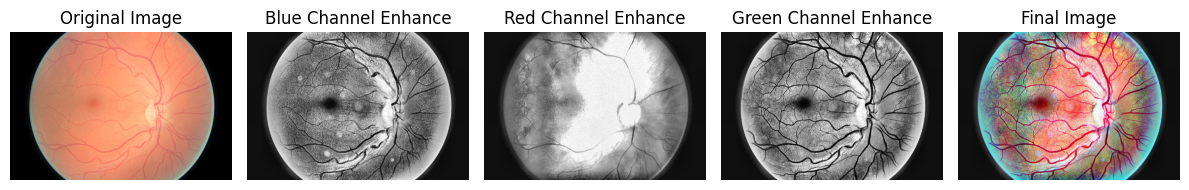

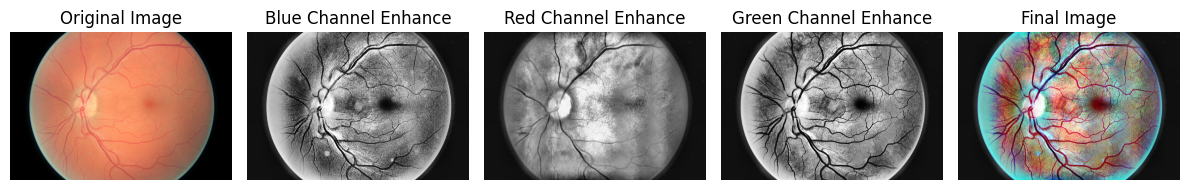

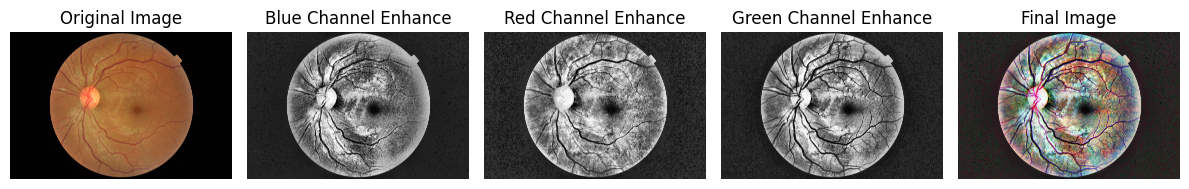

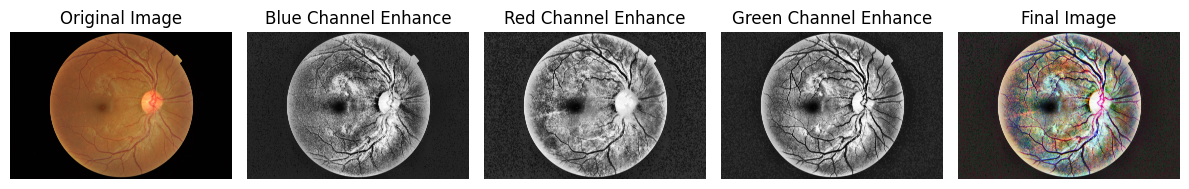

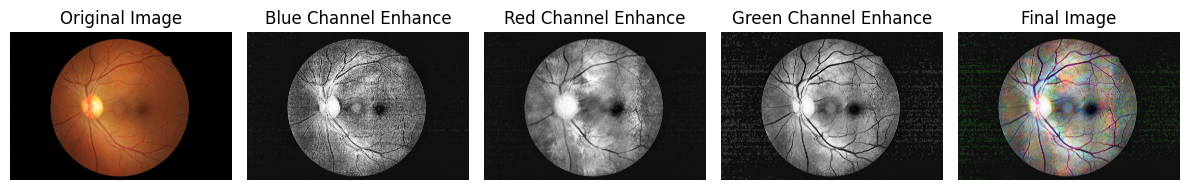

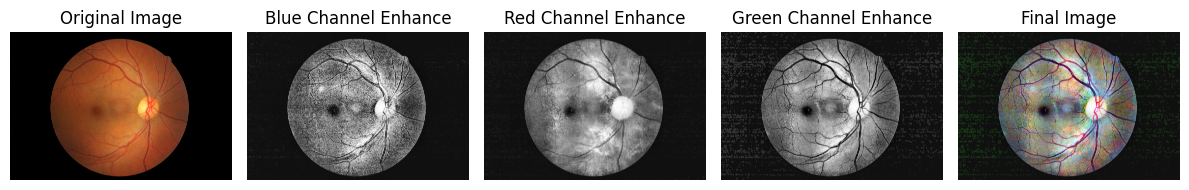

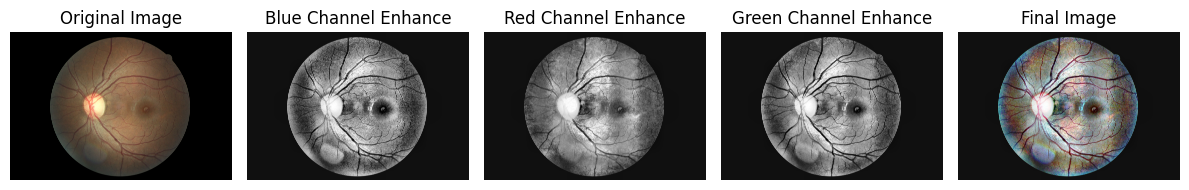

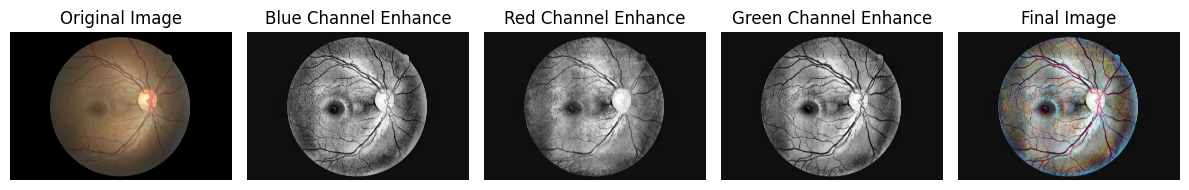

In [32]:


# # Parameters
# img_name = '108_left'
# img_path = 'Inputs/' + img_name + '.jpeg'
# original_image = cv2.imread(img_path)
# b, g, r = cv2.split(original_image)
# rgb = np.dstack([b, g, r])

# enhance(original_image, img_name,G_cl=15,R_cl=15,B_cl=15)


InputFolder = ".\\Inputs"
filesArray = [x for x in os.listdir(InputFolder) if os.path.isfile(os.path.join(InputFolder,x))]

for file_name in filesArray:
    original_image = cv2.imread(InputFolder+"\\"+file_name)
    file_name_no_extension = os.path.splitext(file_name)[0]
    b, g, r = cv2.split(original_image)
    rgb = np.dstack([b, g, r])

    enhance(original_image,file_name_no_extension,G_cl=15,R_cl=15,B_cl=15)
